In [7]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

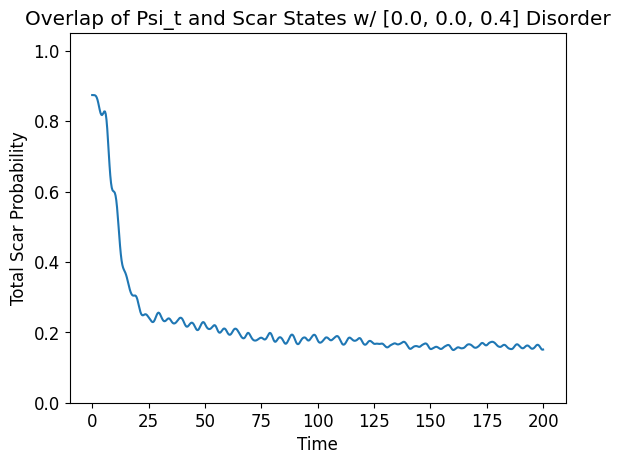

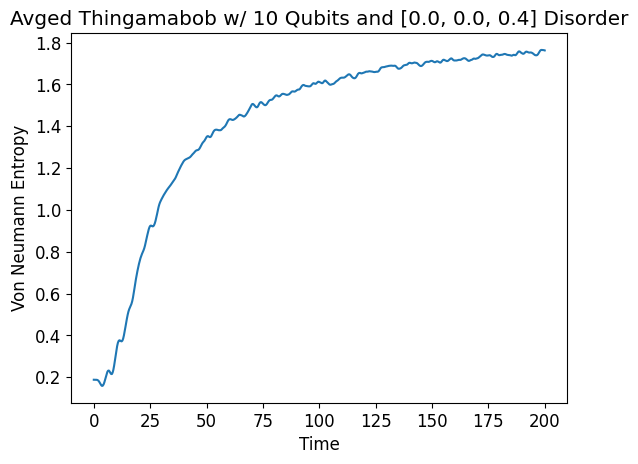

In [16]:
N = 10
wd = 0.6365091993031289
wm = 1.0
tlist = np.linspace(0, 200, 600)
args = {"A": 0.1, "omega": wd}
reals = 50

dx = 0.4
dy = 0.0
dz = 0.0

H0, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)

scarIndices, scarStates = giveMeScarOverlap(N, psi0, tlist, disorder=[dz, dy, dx], reals=reals, args=args)

vn_plot = plot_scar_vn_entrop(N, wd, tlist=tlist, disorder=[dz, dy, dx], reals=reals)

In [ ]:

eigenvalues = H0.eigenenergies()
xlist = np.linspace(0, len(eigenvalues), len(eigenvalues))
plt.plot(xlist, eigenvalues, ".", ms=12)

slist = []
scarVals = []
for i in scarIndices:
    slist.append(xlist[i])
    scarVals.append(eigenvalues[i])

plt.plot(slist, scarVals, ".", ms=12)
plt.grid(True)
plt.xlabel("Eigenvalue")
plt.ylabel("Energy")
plt.grid(True, alpha=0.4)
plt.title(f"Energies of Eigenvalues N={N}")
plt.show()

In [9]:
tol = 1e-8
eigs = eigenvalues
non_degen_states = []

for idx, val in enumerate(eigs):
    close_count = np.sum(np.abs(eigs - val) < tol)
    
    if close_count == 1:
        non_degen_states.append(idx)

print(non_degen_states) # excludes center scar

print(len(non_degen_states) - len(scarIndices) + 1)

# 4, 12, 40, 96, 248, 596
# 2, 6, 20, 48, 124, 298
# 2, 4, 14, 28, 76, 174

[0, 1, 6, 11, 18, 25, 26, 33, 36, 43, 44, 78, 79, 86, 89, 96, 97, 104, 111, 116, 121, 122]
12
